In [ ]:
import os
import numpy as np
from PIL import Image
import cv2
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
from fluo_ts_assay import extract_image_with_mask
import plotly.express as px
import plotly.graph_objects as go
from scipy.ndimage import gaussian_filter1d
import tqdm
import colorsys
from scipy.signal import savgol_filter
import seaborn as sns

In [11]:

#文件位置要改
dir='20pegYS'
path = 'D:/Research/mf_series/'+dir+'/fluo/'
mask_path='D:/Research/mf_series/'+dir+'/mask/Mask.tif'
normmask_path='D:/Research/mf_series/'+dir+'/mask/nMask.tif'

files_list = os.listdir(path)
files_list.sort()

#timegap,要改
time_gap=15



In [3]:
def extract_submatrix(matrix):
    # 获取矩阵的形状
    m, n = matrix.shape[:2]
    
    # 找到矩形区域的左上角和右下角坐标
    top_left = None
    bottom_right = None
    
    for i in range(m):
        for j in range(n):
            if matrix[i, j][3] == 255:
                if top_left is None:
                    top_left = (i, j)
                bottom_right = (i, j)
    
    if top_left is None or bottom_right is None:
        raise ValueError("没有找到符合条件的区域")

    p, q = bottom_right[0] - top_left[0] + 1, bottom_right[1] - top_left[1] + 1   

    submatrix = np.zeros((p, q), dtype=int)

    for i in range(p):
        for j in range(q):
            submatrix[i, j] = matrix[top_left[0] + i, top_left[1] + j][1]

    return submatrix.T

#提取box中荧光强度的值用于归一化
def normed_1(image_path,nor_mask_path):
    img=np.array(extract_image_with_mask(image_path, nor_mask_path))
    norm_area=extract_submatrix(img)
    #取得norm_area的平均值
    norm_value=np.mean(norm_area)
    return norm_value

def color_generator(cmap_name='tab20', num_colors=100):
    cmap = plt.get_cmap(cmap_name)  # 获取指定的colormap
    colors = [cmap(i) for i in range(num_colors)]  # 提取指定数量的颜色
    for color in colors:  # 遍历生成颜色
        yield color


# 定义一个函数来检测水平线与曲线的第一个交点，并返回交点的横坐标
def find_first_intersection(x, y, horizontal_y):
    """
    查找曲线与水平线的第一个交点的横坐标

    参数:
    - x: 曲线的 x 坐标数组
    - y: 曲线的 y 坐标数组
    - horizontal_y: 水平线的 y 坐标

    返回:
    - 第一个交点的 x 坐标，如果没有交点，返回 None
    """
    for i in range(1, len(x)):
        if (y[i-1] - horizontal_y) * (y[i] - horizontal_y) < 0:  # 检测跨过水平线
            # 线性插值求第一个交点的横坐标
            x_inter = x[i-1] + (horizontal_y - y[i-1]) * (x[i] - x[i-1]) / (y[i] - y[i-1])
            return x_inter  # 找到第一个交点后立即返回
    return None  # 如果没有找到交点，返回 None

#将DataFrame中大于k的值替换为None
def replace_outliers(df, k):
    for col in df.columns:
        df[col] = df[col].apply(lambda x: x if x < k else None
                                if x > k else x)
    return df

def length_calculate(L,intersection_list):
    length_list=[]
    for i in range(len(intersection_list)-1):
        length_list.append(intersection_list[i]*L)
    #平滑处理
    length_list=savgol_filter(length_list, 31, 3)
    #所有值减去第一个值
    length_list=[x-length_list[0] for x in length_list]
    return length_list

def find_max(points):
    """
    找到曲线的y最大值及其对应x坐标
    参数：points - 包含曲线坐标的二维数组，形状为(N,2)
    返回：(x_max, y_max) 元组
    """
    y_values = points[:, 1]
    max_index = np.argmax(y_values)
    y_max = y_values[max_index]
    x_max = points[max_index, 0]
    return (x_max, y_max)

def find_width(points):
    """
    计算半高宽（y=(y_max+1)/2处两交点x坐标差）
    参数：points - 包含曲线坐标的二维数组，形状为(N,2)
    返回：宽度值（浮点数）
    """
    x_coords = points[:, 0]
    y_coords = points[:, 1]
    _, y_max = find_max(points)
    target_y = (y_max + 1) / 2
    
    # 寻找所有交点
    intersections = []
    for i in range(1, len(x_coords)):
        y_prev, y_curr = y_coords[i-1], y_coords[i]
        if (y_prev < target_y and y_curr >= target_y) or (y_prev > target_y and y_curr <= target_y):
            # 线性插值计算精确交点
            dx = x_coords[i] - x_coords[i-1]
            dy = y_curr - y_prev
            t = (target_y - y_prev) / dy
            intersections.append(x_coords[i-1] + t * dx)
    
    if len(intersections) >= 2:
        return abs(intersections[-1] - intersections[0])
    raise ValueError("未找到足够交点计算宽度")

In [ ]:
#绘制高清矢量大图
# 假设这些函数已经定义好
# from your_module import extract_image_with_mask, extract_submatrix, normed_1, color_generator

# --- 1. 设置全局样式 (Graphpad风格) ---

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
mpl.rcParams['legend.fontsize'] = 8
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['xtick.major.size'] = 4
mpl.rcParams['ytick.major.size'] = 4
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['figure.subplot.left'] = 0.15
mpl.rcParams['figure.subplot.bottom'] = 0.15
mpl.rcParams['figure.subplot.right'] = 0.9
mpl.rcParams['figure.subplot.top'] = 0.9
mpl.rcParams['savefig.dpi'] = 300

t=0s finished
t=90s finished
t=180s finished
t=270s finished
t=360s finished
t=450s finished
t=540s finished
t=630s finished
t=720s finished
t=810s finished
t=900s finished
t=990s finished
t=1080s finished
t=1170s finished
t=1260s finished
t=1350s finished
t=1440s finished
t=1530s finished
t=1620s finished
t=1710s finished


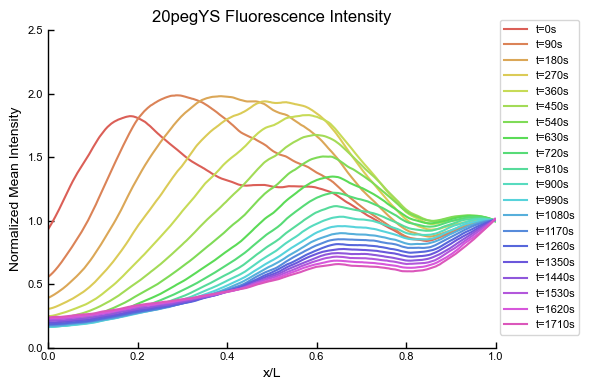

In [13]:

#要改
drawgap = 6
timeuplimit =120

# --- 使用 seaborn 调色板 ---
# 获取一个包含多个颜色的调色板，例如 "tab20" 或 "husl"
palette = sns.color_palette("hls", n_colors=int(timeuplimit/drawgap)+2) # 确保颜色数量足够
# 或者使用 "tab20", 它有 20 种不同的颜色
# palette = sns.color_palette("tab20")
# 可以用以下代码查看palette的颜色
# sns.palplot(palette)
# plt.show()
# 如果你觉得颜色不够亮丽，可以使用更鲜艳的调色板，比如"hls"或者"Set1"
# palette = sns.color_palette("Set1", n_colors=int(timeuplimit/drawgap)+2)

# --- 2. 数据处理和绘图 ---

# 假设这些变量已经定义
# path, mask_path, normmask_path, files_list, time_gap, dir
fig, ax = plt.subplots(figsize=(6, 4))  # 设置图形大小

t = 0
color_index=0
for file in files_list:
    if t % drawgap == 0 and t < timeuplimit:
        file_path = os.path.join(path, file)
        result = extract_image_with_mask(file_path, mask_path)
        result = extract_submatrix(np.array(result))
        result = result
        df = pd.DataFrame(result)
        normed_value = normed_1(file_path, normmask_path)

        row_means = df.mean(axis=1)

        row_means = row_means / normed_value
        x_values = np.arange(0, 1, 1 / len(row_means))

        x_values=x_values[0:len(row_means)]

        smoothed_means2 = savgol_filter(row_means, 51, 3)

        # lincolor = next(colors) # 如果需要自定义颜色, lincolor需为RGB元组或十六进制颜色代码
        
        line, = ax.plot(x_values, smoothed_means2, 
                         label=f't={time_gap * t}s',
                         color=palette[color_index],
                         linewidth=1.5)
        


        print(f't={time_gap * t}s finished')
        color_index+=1

    t += 1

# --- 3. 设置图表细节 ---

ax.set_title(f'{dir} Fluorescence Intensity', fontsize=12)
ax.set_xlabel('x/L', fontsize=10)
ax.set_ylabel('Normalized Mean Intensity', fontsize=10)
#范围，可以改
ax.set_xlim(0, 1)
ax.set_ylim(0,2.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
# ax.grid(True, linestyle='--', alpha=0.5)  # 可选：添加浅灰色网格

# --- 4. 图例 ---

ax.legend(loc='upper right', frameon=True,bbox_to_anchor=(1.2, 1.05))  # 将图例设置到右上角，并去除边框

# --- 5. 调整布局和保存 ---

plt.tight_layout()
plt.savefig(f'D:/Research/mf_series/{dir}/{dir}_int.svg')
plt.show()


In [6]:
#找到归一化后的交点位置，最大值位置，半高宽，保存在同一个excel文件的三个表格中
#文件位置要改
dir='27YS-1'
path = 'D:/Research/mf_series/'+dir+'/fluo/'
mask_path='D:/Research/mf_series/'+dir+'/mask/Mask.tif'
normmask_path='D:/Research/mf_series/'+dir+'/mask/nMask.tif'

files_list = os.listdir(path)
files_list.sort()


y_horizental=40
colors=color_generator(num_colors=100)
intersection_list=[]

t1=0
for file in files_list:
        file_path = os.path.join(path, file)
        result=extract_image_with_mask(file_path,mask_path)
        result=extract_submatrix(np.array(result))
        result=result
        # 将数据转换为DataFrame以便于处理
        df = pd.DataFrame(result)
        #相分离过多则需要替换
        #df=replace_outliers(df, 210)
        row_means=df.mean(axis=1)

        # 计算平滑后的行均值
        smoothed_means2=savgol_filter(row_means, 51, 3)
        # 添加平滑后的行均值
        intersection=find_first_intersection(x_values,smoothed_means2,y_horizental)
        intersection_list.append(intersection)
        if t1%10==0:
            print('t='+str(time_gap*t1)+'s finished')
        t1+=1
#将intersection_list写入csv文件,空缺值用-1填充
df=pd.DataFrame(intersection_list)
df.to_csv('D:/Research/mf_series/'+dir+'/intersection.csv',index=False,header=False)
print('intersection.csv finished')



t=0s finished
t=150s finished
t=300s finished
t=450s finished
t=600s finished
t=750s finished
t=900s finished
t=1050s finished
t=1200s finished
t=1350s finished
intersection.csv finished


[[array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])], [array([ 37.5,  50. ,  75. , 100. , 125. , 150. ])]]


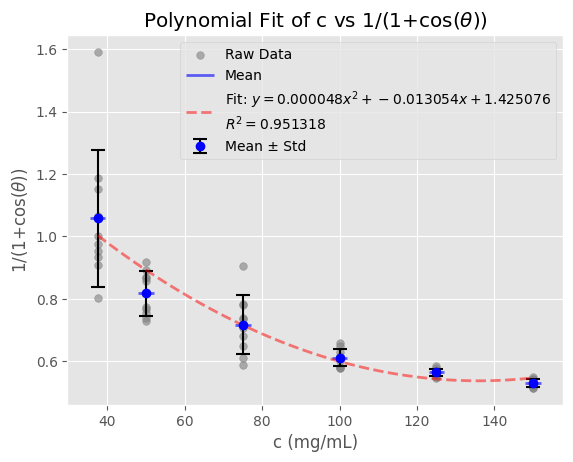

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#拟合c和(1+cos\theta)的关系，在图表中展示结果。加上errorbar
data=pd.read_excel('angles.xlsx')
from scipy.optimize import curve_fit
c_values=data.columns[1:]
#c_values的每个数值除以2
c_values=[x/2 for x in c_values]
c_values=np.array(c_values)
inv_cos_theta=data.iloc[:,1:]
mean_inv_cos_theta=inv_cos_theta.mean()
std_inv_cos_theta=inv_cos_theta.std()
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# 拟合数据
popt, pcov = curve_fit(poly_func, c_values, mean_inv_cos_theta)

# 计算R^2
residuals = mean_inv_cos_theta - poly_func(c_values, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((mean_inv_cos_theta - np.mean(mean_inv_cos_theta))**2)
r_squared = 1 - (ss_res / ss_tot)

# 生成更密集的x值用于绘制连续曲线
x_fit = np.linspace(min(c_values), max(c_values), 500)
y_fit = poly_func(x_fit, *popt)


# 横向分散数据点以避免重叠
x_scatter=[]
for i in range(inv_cos_theta.shape[0]):
    x_scatter.append([c_values])

print(x_scatter)
# 绘图
plt.style.use('ggplot')

# 绘制原始数据点
plt.scatter(x_scatter, inv_cos_theta, color='gray', alpha=0.6, s=30, label='Raw Data')

# 绘制均值横线
for c, mean_val in zip(c_values, mean_inv_cos_theta):
    plt.hlines(mean_val, c - 2, c + 2, color='blue', linestyle='-', linewidth=2, label='Mean' if c == c_values[0] else "", alpha=0.6)

# 绘制误差棒
plt.errorbar(c_values, mean_inv_cos_theta, yerr=std_inv_cos_theta, fmt='o', 
             color='blue', ecolor='black', elinewidth=1.5, capsize=5, capthick=1.5, label='Mean ± Std')

# 绘制拟合曲线
plt.plot(x_fit, y_fit, 'r--', alpha=0.5, linewidth=2, 
         label=f'Fit: $y = {popt[0]:.6f}x^2 + {popt[1]:.6f}x + {popt[2]:.6f}$\n$R^2 = {r_squared:.6f}$')

# 图形设置
plt.xlabel('c (mg/mL)')
plt.ylabel('1/(1+cos($\\theta$))')
plt.legend(loc='best', frameon=True)
plt.title('Polynomial Fit of c vs 1/(1+cos($\\theta$))')

# 保存为.svg矢量图
plt.savefig('fit_plot.svg', format='svg', bbox_inches='tight')

# 显示图形
plt.show()

正在读取数据...
错误: 无法读取数据文件 ('utf-8' codec can't decode byte 0x82 in position 16: invalid start byte)
正在拟合参数...
参数拟合成功: Lambda=1.5595, C=1.3623
图表已生成并保存为: tension_fit_nature_style.svg


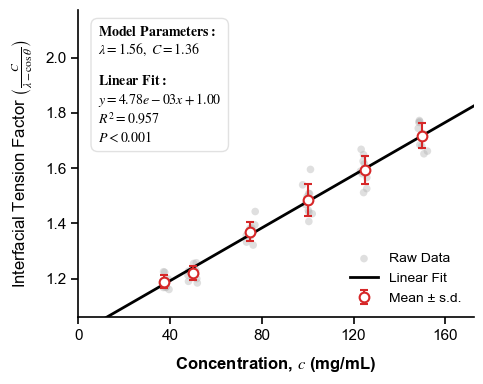

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.ticker as ticker
import sys

# ---------------------------------------------------------
# 1. 数据加载与预处理
# ---------------------------------------------------------
filename = 'angles.xlsx'

print("正在读取数据...")
try:
    df = pd.read_csv(filename)
    
    # 转换数据格式: Wide -> Long
    id_col = df.columns[0] 
    concentration_cols = df.columns[1:]
    
    df_melted = df.melt(id_vars=[id_col], 
                        value_vars=concentration_cols,
                        var_name='Replicate', 
                        value_name='CosTheta')
    
    df_melted.rename(columns={id_col: 'Concentration'}, inplace=True)

    # 确保数据为数值型
    df_melted['Concentration'] = pd.to_numeric(df_melted['Concentration'], errors='coerce')
    df_melted['CosTheta'] = pd.to_numeric(df_melted['CosTheta'], errors='coerce')
    
    # 移除无效数据
    df_melted.dropna(subset=['Concentration', 'CosTheta'], inplace=True)
    
    print(f"数据加载成功: {len(df_melted)} 个数据点")

except Exception as e:
    print(f"错误: 无法读取数据文件 ({e})")
    # 生成模拟数据以供测试
    np.random.seed(42)
    concs = np.array([37.5, 50, 75, 100, 125, 150])
    data = []
    for c in concs:
        base_cos = 1.2 - 1.1 / (1 + 0.01 * c) 
        vals = np.clip(np.random.normal(base_cos, 0.03, 10), -0.9, 0.95)
        for v in vals:
            data.append({'Concentration': c, 'CosTheta': v})
    df_melted = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. 物理模型拟合 (确定 Lambda 和 C)
# ---------------------------------------------------------

# 理论模型: Tension_Factor ~ 1 + alpha * c
# 对应 CosTheta 模型: cos_theta = lam - C_val / (1 + alpha * c)
def model_cos_theta(c, lam, C_val, alpha):
    denom = 1.0 + alpha * c
    denom[denom < 1e-5] = 1e-5 
    return lam - C_val / denom

# 初始猜测值
p0 = [1.2, 1.2, 0.01]
bounds = ([1.001, 0.0, 0.0], [5.0, 5.0, 10.0])

print("正在拟合参数...")
try:
    popt, pcov = curve_fit(model_cos_theta, 
                           df_melted['Concentration'], 
                           df_melted['CosTheta'], 
                           p0=p0, 
                           bounds=bounds,
                           maxfev=10000)
    
    LAMBDA_OPT, C_OPT, ALPHA_OPT = popt
    print(f"参数拟合成功: Lambda={LAMBDA_OPT:.4f}, C={C_OPT:.4f}")

except Exception as e:
    print(f"拟合失败: {e}")
    LAMBDA_OPT, C_OPT, ALPHA_OPT = 1.5, 1.4, 0.01

# ---------------------------------------------------------
# 3. 数据转换与线性回归分析
# ---------------------------------------------------------
# 计算核心物理量 Y = C / (Lambda - CosTheta)
df_melted['Y_Value'] = C_OPT / (LAMBDA_OPT - df_melted['CosTheta'])

# 对转换后的数据进行线性回归，获取统计指标 (R^2, P-value)
slope, intercept, r_value, p_value, std_err = stats.linregress(df_melted['Concentration'], df_melted['Y_Value'])
r_squared = r_value**2

# 计算绘图用的统计量 (Mean & Std)
stats_df = df_melted.groupby('Concentration')['Y_Value'].agg(['mean', 'std']).reset_index()

# ---------------------------------------------------------
# 4. 绘图 (Nature/Science 风格)
# ---------------------------------------------------------
# 设置全局字体为 Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'stix' # 公式使用 STIX 字体 (类似 Times 罗马体)

fig, ax = plt.subplots(figsize=(5, 4)) 

# 4.1 绘制原始数据散点 (Scatter with Jitter)
jitter_strength = (df_melted['Concentration'].max() - df_melted['Concentration'].min()) * 0.02
np.random.seed(0)
x_jittered = df_melted['Concentration'] + np.random.uniform(-jitter_strength, jitter_strength, len(df_melted))

ax.scatter(x_jittered, df_melted['Y_Value'], 
           color='#B0B0B0',       # 浅灰色
           alpha=0.4,             # 半透明
           s=30,                  
           edgecolors='none', 
           label='Raw Data', 
           zorder=1)

# 4.2 绘制均值和误差棒
ax.errorbar(stats_df['Concentration'], stats_df['mean'], yerr=stats_df['std'], 
            fmt='o', 
            color='#D62728',      # Science Red
            ecolor='#D62728', 
            elinewidth=1.5, 
            capsize=3, 
            markersize=7, 
            markerfacecolor='white', 
            markeredgewidth=1.5, 
            label='Mean ± s.d.', 
            zorder=3)

# 4.3 绘制线性拟合直线
x_fit = np.linspace(0, df_melted['Concentration'].max() * 1.15, 100)
y_fit = slope * x_fit + intercept

ax.plot(x_fit, y_fit, 
        color='black',          
        linewidth=2.0, 
        linestyle='-', 
        label='Linear Fit', 
        zorder=2)

# 4.4 坐标轴设置
ax.set_xlabel(r'Concentration, $c$ (mg/mL)', fontsize=12, weight='bold', labelpad=8)
ax.set_ylabel(r'Interfacial Tension Factor $\left( \frac{C}{\lambda - \cos \theta} \right)$', fontsize=12, labelpad=8)

# 去除上方和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 刻度设置
ax.tick_params(direction='out', length=5, width=1.2, colors='black', labelsize=11)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

# 设置坐标范围
y_min, y_max = df_melted['Y_Value'].min(), df_melted['Y_Value'].max()
ax.set_ylim(y_min - 0.1, y_max + 0.4) # 顶部留出更多空间
ax.set_xlim(0, df_melted['Concentration'].max() * 1.15)

# 4.5 添加统计信息和公式文本
# 格式化 P 值
if p_value < 0.001:
    p_text = "P < 0.001"
else:
    p_text = f"P = {p_value:.3f}"

# 构建显示文本
info_text = (
    r"$\bf{Model\ Parameters:}$" + "\n" +
    rf"$\lambda = {LAMBDA_OPT:.2f}, \ C = {C_OPT:.2f}$" + "\n\n" +
    r"$\bf{Linear\ Fit:}$" + "\n" +
    rf"$y = {slope:.2e}x + {intercept:.2f}$" + "\n" +
    rf"$R^2 = {r_squared:.3f}$" + "\n" +
    rf"${p_text}$"
)

ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.95, edgecolor='#E0E0E0', linewidth=1))

# 图例
ax.legend(frameon=False, loc='lower right', fontsize=10)

plt.tight_layout()

# 保存
output_file = 'tension_fit_nature_style.svg'
plt.savefig(output_file, format='svg', dpi=300, transparent=True)
print(f"图表已生成并保存为: {output_file}")
plt.show()

NameError: name 'color_generator' is not defined

In [18]:


# 2. Plot the intersection points,df to list
#intersection_list_1=pd.read_csv('D:/Research/mf_series/0.3triton_200_1/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_2=pd.read_csv('D:/Research/mf_series/20peg200_1/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_3=pd.read_csv('D:/Research/mf_series/10peg+200_7/intersection.csv',header=None).iloc[:, 0].tolist()
#intersection_list_4=pd.read_csv('D:/Research/mf_series/40peg+100_1/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_5=pd.read_csv('D:/Research/mf_series/bsa_200_1/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_6=pd.read_csv('D:/Research/mf_series/5peg+200_1/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_7=pd.read_csv('D:/Research/mf_series/1triton_200/intersection.csv',header=None).iloc[:, 0].tolist()
#intersection_list_8=pd.read_csv('D:/Research/mf_series/40peg200_1/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_9=pd.read_csv('D:/Research/mf_series/40peg200_2/intersection.csv',header=None).iloc[:, 0].tolist()
intersection_list_10=pd.read_csv('D:/Research/mf_series/27YS-1/intersection.csv',header=None).iloc[:, 0].tolist()


time_gap=30

fig = go.Figure()
#fig.add_trace(go.Scatter(x=[30*t for t in range(len(intersection_list_1))], y=length_calculate(373,intersection_list_1), mode='lines+markers',name='0.3% Triton X-100'))
fig.add_trace(go.Scatter(x=[15*t for t in range(len(intersection_list_2))], y=length_calculate(564,intersection_list_2), mode='lines+markers',name='20% PEG'))
fig.add_trace(go.Scatter(x=[10*t for t in range(len(intersection_list_3))], y=length_calculate(455,intersection_list_3), mode='lines+markers',name='10% PEG'))
#fig.add_trace(go.Scatter(x=[10*t for t in range(len(intersection_list_4))], y=length_calculate(500,intersection_list_4), mode='lines',name='40% PEG'))
fig.add_trace(go.Scatter(x=[60*t for t in range(len(intersection_list_5))], y=length_calculate(303,intersection_list_5), mode='lines+markers',name='BSA'))
fig.add_trace(go.Scatter(x=[10*t for t in range(len(intersection_list_6))], y=length_calculate(455,intersection_list_6), mode='lines+markers',name='5% PEG'))
#fig.add_trace(go.Scatter(x=[30*t for t in range(len(intersection_list_7))], y=length_calculate(373,intersection_list_7), mode='lines+markers',name='1% Triton X-100'))
#fig.add_trace(go.Scatter(x=[10*t for t in range(len(intersection_list_8))], y=length_calculate(300,intersection_list_8), mode='lines+markers',name='40% PEG'))
fig.add_trace(go.Scatter(x=[10*t for t in range(len(intersection_list_9))], y=length_calculate(437,intersection_list_9), mode='lines+markers',name='40% PEG'))
fig.add_trace(go.Scatter(x=[30*t for t in range(len(intersection_list_10))], y=length_calculate(540,intersection_list_10), mode='lines+markers',name='27YS-20%PEG'))
fig.update_layout(
    title='Frontier Moving Dynamics',
    xaxis_title='Time (s)',
    yaxis_title='Frontier Position (μm)',
    width=1000,
    height=800,
    xaxis=dict(range=[0, time_gap*len(intersection_list_2)],zeroline=True,showline=True,showgrid=True,mirror='ticks',ticks='outside'),
    yaxis=dict(zeroline=True,showline=True,showgrid=True,mirror='ticks',ticks='outside'),
    plot_bgcolor='rgba(255,255,255,0.8)',
    legend=dict(
        font=dict(
            size=20  # 图例字体大小
        )
    )
)
fig.show()

In [17]:
conc_intersection_list_1=pd.read_csv('D:/Research/mf_series/20peg200_1/intersection.csv',header=None).iloc[:, 0].tolist()
conc_intersection_list_2=pd.read_csv('D:/Research/mf_series/20peg100_2/intersection.csv',header=None).iloc[:, 0].tolist()
conc_intersection_list_3=pd.read_csv('D:/Research/mf_series/20peg50_1/intersection.csv',header=None).iloc[:, 0].tolist()

fig = go.Figure()
fig.add_trace(go.Scatter(x=[10*t for t in range(len(conc_intersection_list_1))], y=length_calculate(564,conc_intersection_list_1), mode='lines+markers',name='200μM'))
fig.add_trace(go.Scatter(x=[10*t for t in range(len(conc_intersection_list_2))], y=length_calculate(458,conc_intersection_list_2), mode='lines+markers',name='100μM'))
fig.add_trace(go.Scatter(x=[10*t for t in range(len(conc_intersection_list_3))], y=length_calculate(540,conc_intersection_list_3), mode='lines+markers',name='50μM'))

                         
fig.update_layout(
    title='Frontier Moving Dynamics',
    xaxis_title='Time (s)',
    yaxis_title='Frontier Position (μm)',
    width=1000,
    height=800,
    xaxis=dict(range=[0, time_gap*len(intersection_list)],zeroline=True,showline=True,showgrid=True,mirror='ticks',ticks='outside'),
    yaxis=dict(zeroline=True,showline=True,showgrid=True,mirror='ticks',ticks='outside'),
    plot_bgcolor='rgba(255,255,255,0.8)',
    legend=dict(
        font=dict(
            size=20  # 图例字体大小
        )
    )
)
fig.show()